# So you'd like to enumerate with YARP-again

## Step 1: Get YARP-again working!

Clone the git repository:
```
git clone git@github.com:Savoie-Research-Group/yarp-again.git
```

Checkout the correct version of the code:
```
git checkout enum
```

Set up a conda environment from the base directory of the git repo:
```
cd yarp-again
conda env create -f environment.yml
conda activate yarp-again
```

Do a local pip installation from the base directory of the git repo:
```
pip install -e .
```

Once you do all these steps, this cell should run without errors.

In [1]:
import numpy as np
import yarp as yp
from yarp.reaction.generate_rxns import enumerate_products, quick_geom_opt
from yarp.reaction.enum import break_bonds, form_n_bonds

## Step 2: Initialize a yarpecule object

Stick to initializing from XYZ files for now, save yourself some grief!

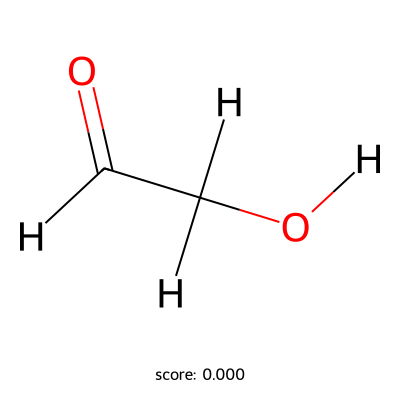

In [2]:
file_path = "../test/molecules/haa.xyz"
haa = yp.yarpecule(file_path, canon=True) # if you don't want a "canonical ordering", set canon to False (default = True)
haa.draw_bmats(show_inline=True)

# use this if you want to actually generate a PDF image (i.e. you're not using a python notebook)
# haa.draw_bmats(outfile="output_file.pdf") 

## Step 3: Enumerate some products!

### More user-friendly option

Using the `enumerate_products()`, as defined in `yarp/reaction/generate_rxns.py`:

***
```
def enumerate_products(r_yp, n_break, n_form, react=[], mode="sequential", lewis_filter=True, cutoff=0.0, ring_filter=False):

    r_yp : yarpecule object
        The reactant from which all products are enumerated

    n_break : int
        Number of bonds to break

    n_form : int
        Number of bonds to form

    react : set (default = None)
        When supplied this is used to restrict bond formations only to those atoms in this set.
        If supplied, then `react` must have a searchable list or set
        (i.e., the function uses an `in` call, so sets are better) per `yarpecule`.
        An empty list is interpreted as all atoms being available to react. 

    mode : string
        Toggle between the two available product enumeration modes:
        Concerted and sequential (default) enumeration.

    lewis_filter : bool (default = True)
        Filter out enumerated products based on bond-electron matrix scores and formal charges.

    cutoff : float (default = 0.0)
        Threshold used in sequential enumeration to discard unphysical Lewis structures
        with bond-electron matrix scores above this value.

    ring_filter : bool (default = False)
        Filter out 3 and 4 member rings from enumerated products.

```
***  

In [3]:
haa_prods = enumerate_products(haa, 2, 2)

# Uncomment if you want a quick visual
# for _ in haa_prods:
#    _.draw_bmats(show_inline=True)

 - Product enumeration with break 2, form 2 will be performed in sequential mode.
   + Breaking 2 bonds formed 15 intermediates
   + Forming 2 bonds formed 102 potential products
   + 11 cleaned products after filtering


### More nuanced control option

Directly call the underlying `break_bonds` and `form_n_bonds` as defined in `yarp/reaction/enum.py`

In [4]:
haa_break_intermediates = list(break_bonds(haa, 2)) # can include react option here to limit atoms you want to allow bonds to break for

# Uncomment if you want a quick visual
# for _ in haa_break_intermediates:
#    _.draw_bmats(show_inline=True)

In [5]:
haa_products = form_n_bonds(haa_break_intermediates, n=2, react=[], hashes={haa.hash}) # if you don't include your initial yarpecule hash here, you might reform the original reactant

You'll then need to manually perform any desired filtering

In [6]:
# Filter out based on bond-electron matrix score
haa_products = [_ for _ in haa_products if _.bond_mat_scores[0] <= 0.0 and sum(np.abs(_.fc)) < 2.0]

In [7]:
# Filter out 3 and 4 member rings (you probably don't want to do this for your stuff right now)
product = []
for _ in haa_products:
    if _.rings != []:
        if len(_.rings[0]) > 4:
            product.append(_)
    else:
        product.append(_)
haa_products = product

## Step 4: Snap product geometries into place via UFF optimization

Be warned: This might throw some errors upon execution if it encounters any exotic species!

But once it successfully executes, you should have updated geometry coordinates stored in your product yarpecules

In [8]:
print("Geometry before quick opt:")
print(haa_prods[0].geo)

for prod in haa_prods:
    prod = quick_geom_opt(prod)

print("Geometry after quick opt:")
print(haa_prods[0].geo)

Geometry before quick opt:
[[ 3.22914 -1.11546  1.1381 ]
 [ 2.07039 -0.30176  0.63695]
 [ 4.41407 -0.73264  0.42993]
 [ 2.01207 -0.0193  -0.54855]
 [ 5.16047 -1.24039  0.72773]
 [ 3.02664 -2.18356  0.96518]
 [ 3.36528 -0.94099  2.21642]
 [ 1.13212 -0.3485   1.18841]]
Geometry after quick opt:
[[ 3.1826612  -1.53019858  1.343896  ]
 [ 2.69136548 -0.40205347  0.44953409]
 [ 3.39854849  0.76332999  0.60106031]
 [ 3.61225981 -0.00622248 -0.48665366]
 [ 2.95021657 -2.50431754  0.86591181]
 [ 4.27929052 -1.46437923  1.5141651 ]
 [ 2.66229876 -1.47502873  2.32246036]
 [ 1.63375917 -0.26382995  0.14352599]]


## Step 5: Export product geometries as XYZ files

Hopefully this works! I haven't really tested it, but it seems like it works!

In [9]:
haa_prods[0].export_geometry("haa_prod_0.xyz")